In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv("ratings.csv")
df = pd.read_csv("movies.csv")
df.head()

Saving movies.csv to movies.csv
Saving ratings.csv to ratings (1).csv


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Ratings Data:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Movies Data:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

USER-BASED RECOMMENDATIONS:
                                               title  predicted_rating
0  Dr. Strangelove or: How I Learned to Stop Worr

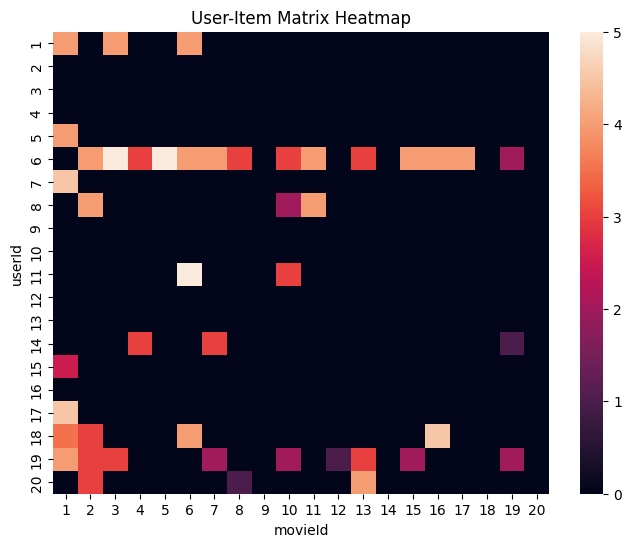

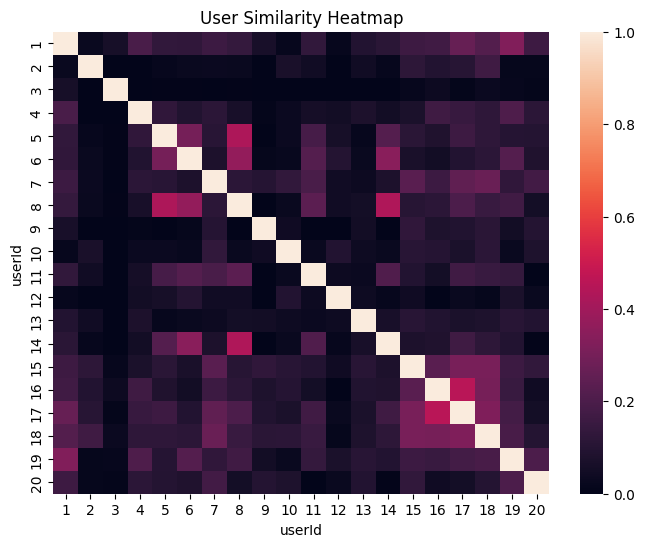

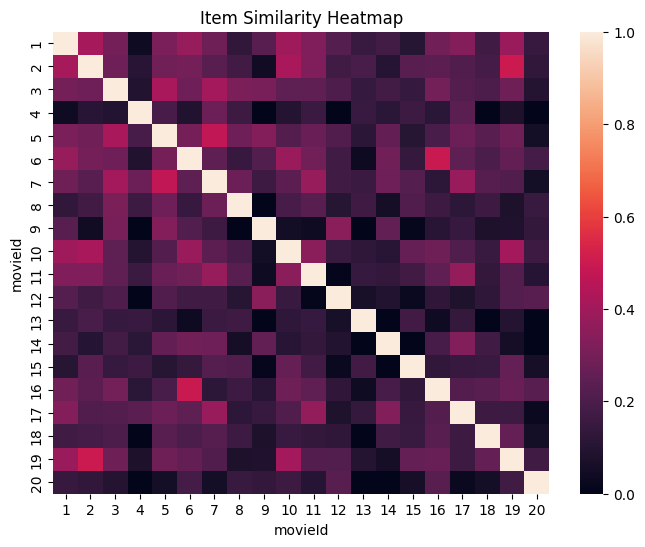

In [ ]:
# ==============================
# COMPLETE RECOMMENDATION SYSTEM
# (USER + ITEM BASED)
# ==============================

# Import Libraries
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# LOAD DATA
# ==============================
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

print("Ratings Data:")
print(ratings.head())

print("\nMovies Data:")
print(movies.head())

# ==============================
# USER-BASED COLLABORATIVE FILTERING
# ==============================

# Create User-Item Matrix
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

# Fill Missing Values
user_item_filled = user_item_matrix.fillna(0)

# Compute User Similarity
user_similarity = cosine_similarity(user_item_filled)

user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_filled.index,
                                 columns=user_item_filled.index)

# Get Similar Users
def get_similar_users(user_id, n=5):
    return user_similarity_df[user_id].sort_values(ascending=False)[1:n+1]

# Predict Ratings
def predict_ratings(user_id):
    similar_users = get_similar_users(user_id)
    user_ratings = user_item_filled.loc[user_id]
    pred = {}

    for movie in user_item_filled.columns:
        if user_ratings[movie] == 0:
            num, den = 0, 0
            for sim_user, sim_score in similar_users.items():
                rating = user_item_filled.loc[sim_user, movie]
                if rating > 0:
                    num += sim_score * rating
                    den += sim_score
            if den != 0:
                pred[movie] = num / den

    return pd.Series(pred)

# Recommend Movies (WITH NAMES)
def recommend_movies(user_id, top_n=5):
    preds = predict_ratings(user_id).sort_values(ascending=False).head(top_n)

    rec_df = pd.DataFrame(preds).reset_index()
    rec_df.columns = ['movieId', 'predicted_rating']

    final = pd.merge(rec_df, movies, on='movieId')

    return final[['title', 'predicted_rating']]

print("\nUSER-BASED RECOMMENDATIONS:")
print(recommend_movies(1))

# ==============================
# ITEM-BASED COLLABORATIVE FILTERING
# ==============================

# Create Item-User Matrix
item_user_matrix = ratings.pivot(index='movieId', columns='userId', values='rating')

# Fill Missing
item_user_filled = item_user_matrix.fillna(0)

# Compute Item Similarity
item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=item_user_filled.index,
                                 columns=item_user_filled.index)

# Get Similar Items
def get_similar_items(movie_id, n=5):
    return item_similarity_df[movie_id].sort_values(ascending=False)[1:n+1]

# Recommend Items (WITH NAMES)
def recommend_items(user_id, top_n=5):
    user_data = ratings[ratings['userId'] == user_id]
    scores = {}

    for _, row in user_data.iterrows():
        movie = row['movieId']
        rating = row['rating']
        similar_movies = get_similar_items(movie)

        for sim_movie, sim_score in similar_movies.items():
            scores[sim_movie] = scores.get(sim_movie, 0) + sim_score * rating

    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    rec_df = pd.DataFrame(sorted_scores, columns=['movieId', 'score'])
    final = pd.merge(rec_df, movies, on='movieId')

    return final[['title', 'score']]

print("\nITEM-BASED RECOMMENDATIONS:")
print(recommend_items(1))

# ==============================
# EVALUATION
# ==============================
actual = []
predicted = []

for user in user_item_filled.index[:20]:  # small sample

    similar_users = get_similar_users(user)

    for movie in user_item_matrix.columns:

        if not np.isnan(user_item_matrix.loc[user, movie]):  # actual exists

            num, den = 0, 0

            for sim_user, sim_score in similar_users.items():
                rating = user_item_filled.loc[sim_user, movie]

                if rating > 0:
                    num += sim_score * rating
                    den += sim_score

            if den != 0:
                pred = num / den

                actual.append(user_item_matrix.loc[user, movie])
                predicted.append(pred)

# Check before calculating
if len(actual) > 0:
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)

    print("\n Evaluation:")
    print("RMSE:", rmse)
    print("MAE:", mae)
else:
    print(" No values to evaluate")

# ==============================
# VISUALIZATIONS
# ==============================

# User-Item Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(user_item_filled.iloc[:20, :20])
plt.title("User-Item Matrix Heatmap")
plt.show()

# User Similarity
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20])
plt.title("User Similarity Heatmap")
plt.show()

# Item Similarity
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20])
plt.title("Item Similarity Heatmap")
plt.show()